In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, auc
import statsmodels.api as sm
from statsmodels.formula.api import logit
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from pandas.api.types import CategoricalDtype
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.model_selection import KFold



pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [93]:
def make_design_matrix(df, y_col, x_cols, cat_cols, drop_first=True):
    y = df[y_col].copy()
    X = df[x_cols].copy()

    X = pd.get_dummies(X, columns=cat_cols, drop_first=drop_first)

    bool_cols = X.select_dtypes(include=["bool"]).columns
    if len(bool_cols) > 0:
        X[bool_cols] = X[bool_cols].astype(int)

    X = sm.add_constant(X)
    return y, X

def linear_results_table(model, X, y):
    params = model.params
    se = model.bse
    tvals = model.tvalues
    pvals = model.pvalues

    y_std = y.std(ddof=0)
    beta_std = {}
    for name in params.index:
        if name.lower() == "const":
            beta_std[name] = np.nan
        else:
            x_std = X[name].std(ddof=0)
            beta_std[name] = params[name] * (x_std / y_std) if y_std != 0 else np.nan
    beta_std = pd.Series(beta_std)

    def interpret(b):
        if pd.isna(b): 
            return ""
        return "↑ Trajanje" if b > 0 else "↓ Trajanje"

    table = pd.DataFrame({
        "Spremenljivka": params.index,
        "β (ne-standardiziran)": params.values,
        "β (standardiziran)": beta_std.values,
        "SE": se.values,
        "t": tvals.values,
        "p": pvals.values,
        "Interpretacija": [interpret(b) for b in params.values],
    })

    return table

def ridge_results_table(ridge_pipeline, X, y):
    beta = ridge_pipeline.named_steps["ridge"].coef_
    beta = pd.Series(beta, index=X.columns)
    
    y_std = pd.Series(y).std(ddof=0)
    beta_std = beta * (X.std(ddof=0) / y_std) if y_std != 0 else np.nan

    def interpret(b):
        if pd.isna(b):
            return ""
        return "↑ Trajanje" if b > 0 else "↓ Trajanje"

    table = pd.DataFrame({
        "Spremenljivka": beta.index,
        "β (Ridge)": beta.values,
        "β (standardiziran)": beta_std.values,
        "Interpretacija": [interpret(b) for b in beta.values],
    })

    return table.sort_values("β (Ridge)", key=lambda s: s.abs(), ascending=False)


def ordinal_results_table(model_result):
    params = model_result.params
    se = model_result.bse
    pvals = model_result.pvalues

    def interpret(beta):
        return "↑ višja kategorija Trajanja" if beta > 0 else "↓ nižja kategorija Trajanja"

    table = pd.DataFrame({
        "Spremenljivka": params.index,
        "β": params.values,
        "SE": se.values,
        "p": pvals.values,
        "Interpretacija": [interpret(b) for b in params.values]
    })

    table = table[~table["Spremenljivka"].str.contains("/")].reset_index(drop=True)

    return table

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mcfadden_pseudo_r2(ll_model, ll_null):
    if ll_null == 0 or np.isnan(ll_model) or np.isnan(ll_null):
        return np.nan
    return float(1.0 - (ll_model / ll_null))


def ordinal_to_codes(y_obj):
    if isinstance(y_obj, pd.Categorical):
        return y_obj.codes + 1
    if isinstance(y_obj, pd.Series) and isinstance(y_obj.dtype, pd.CategoricalDtype):
        return y_obj.cat.codes + 1
    y_tmp = pd.Series(y_obj).astype("category")
    return y_tmp.cat.codes + 1

def fit_ordinal(train_y, train_X, distr="logit"):
    m = OrderedModel(train_y, train_X, distr=distr)
    return m.fit(method="bfgs", disp=False)

def ordinal_predict_class(res, X_new, y_ref):
    probs = res.model.predict(res.params, exog=X_new)
    probs = np.asarray(probs)
    idx = probs.argmax(axis=1)

    cats = y_ref.cat.categories
    return pd.Categorical([cats[i] for i in idx], categories=cats, ordered=True)

def ordinal_loglike_on_data(res_params, y_data, X_data, distr="logit"):
    m = OrderedModel(y_data, X_data, distr=distr)
    return float(m.loglike(res_params))

def ordinal_null_loglike(y_data, distr="logit"):
    X0 = np.empty((len(y_data), 0))
    m0 = OrderedModel(y_data, X0, distr=distr)
    r0 = m0.fit(method="bfgs", disp=False)
    return float(r0.llf)


In [73]:

df = pd.read_csv("./expanded_data.csv", sep=",")

df.columns = df.columns.str.strip()

num_cols = ["Iteracija", "Trajanje (h)", "Cakanje (h)", "Napake (st)"]
for c in num_cols:
    df[c] = (df[c].astype(str)
                  .str.replace(",", ".", regex=False)
                  .str.strip())
    df[c] = pd.to_numeric(df[c], errors="coerce")

cat_cols = ["Korak", "Vloga (kdo)", "Tip aktivnosti (VA/NVA)", "Trajanje_kategorija", "Cakanje_intenziteta"]
for c in cat_cols:
    df[c] = df[c].astype("category")

print(df.dtypes)
df.head()

Iteracija                     int64
Korak                      category
Vloga (kdo)                category
Trajanje (h)                float64
Cakanje (h)                 float64
Tip aktivnosti (VA/NVA)    category
Napake (st)                   int64
Trajanje_kategorija        category
Cakanje_intenziteta        category
dtype: object


,Iteracija,Korak,Vloga (kdo),Trajanje (h),Cakanje (h),Tip aktivnosti (VA/NVA),Napake (st),Trajanje_kategorija,Cakanje_intenziteta
0,1,Priprava 3D modela implantata,Raziskovalec,0.83,0.0,VA,0,Srednje,Brez
1,1,Pošiljanje modela v pregled,Raziskovalec,0.12,0.6,NVA,0,Kratko,Zmerno
2,1,Čakanje na odobritev,Vodja laboratorija,2.09,2.2,NVA,1,Dolgo,Dolgo
3,1,Priprava tiskalnika in materiala,Raziskovalec,0.38,0.0,VA,0,Kratko,Brez
4,1,Čakanje na prost tiskalnik,Raziskovalec,1.52,0.0,NVA,0,Dolgo,Brez


In [74]:
y = df["Trajanje (h)"]

X = df[["Korak", "Vloga (kdo)", "Cakanje (h)", "Tip aktivnosti (VA/NVA)", "Napake (st)"]].copy()

X = pd.get_dummies(
    X,
    columns=["Korak", "Vloga (kdo)", "Tip aktivnosti (VA/NVA)"],
    drop_first=True
)

bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

X = sm.add_constant(X)

model_1 = sm.OLS(y, X).fit()
model_1.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Trajanje (h)   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     3.072
Date:                Sun, 14 Dec 2025   Prob (F-statistic):            0.00104
Time:                        23:46:57   Log-Likelihood:                -117.94
No. Observations:                 110   AIC:                             261.9
Df Residuals:                      97   BIC:                             297.0
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
=============================================================================================================
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
const                                         0.6923      0.109      6.366      0.000       0.476       0.908
Cakanje (h)                                  -0.0908      0.137     -0.661      0.510      -0.364       0.182
Napake (st)                                   0.2380      0.461      0.517      0.607      -0.676       1.152
Korak_Hlajenje modela                         0.1225      0.182      0.673      0.503      -0.239       0.484
Korak_Kontrola kakovosti                     -0.0056      0.109     -0.051      0.959      -0.223       0.212
Korak_Odstranjevanje podpornih struktur      -0.3294      0.201     -1.638      0.105      -0.728       0.070
Korak_Označevanje in vpis v dokumentacijo    -0.5045      0.211     -2.387      0.019      -0.924      -0.085
Korak_Ponoven tisk (če napaka)                0.2891      0.209      1.381      0.171      -0.126       0.705
Korak_Pošiljanje modela v pregled             0.0612      0.209      0.292      0.771      -0.354       0.477
Korak_Priprava 3D modela implantata           0.2580      0.202      1.278      0.204      -0.143       0.659
Korak_Priprava tiskalnika in materiala       -0.4113      0.201     -2.046      0.043      -0.810      -0.012
Korak_Čakanje na odobritev                    0.0614      0.123      0.501      0.617      -0.182       0.305
Korak_Čakanje na prost tiskalnik              0.3411      0.212      1.612      0.110      -0.079       0.761
Vloga (kdo)_Kontrolor kakovosti              -0.0056      0.109     -0.051      0.959      -0.223       0.212
Vloga (kdo)_Raziskovalec                     -0.2958      0.093     -3.174      0.002      -0.481      -0.111
Vloga (kdo)_Raziskovalec / tiskalnik          0.8098      0.168      4.818      0.000       0.476       1.143
Vloga (kdo)_Vodja laboratorija                0.0614      0.123      0.501      0.617      -0.182       0.305
Tip aktivnosti (VA/NVA)_NVA                   0.2482      0.094      2.655      0.009       0.063       0.434
Tip aktivnosti (VA/NVA)_VA                    0.3272      0.092      3.554      0.001       0.144       0.510
==============================================================================
Omnibus:                       22.536   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               32.824
Skew:                           0.981   Prob(JB):                     7.45e-08
Kurtosis:                       4.820   Cond. No.                     4.05e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.75e-31. This might indicate that there are
strong multic

In [75]:
table_1 = linear_results_table(model_1, X, y)
table_1

,Spremenljivka,β (ne-standardiziran),β (standardiziran),SE,t,p,Interpretacija
0,const,0.692271,NaN,0.108750,6.365728,6.458536e-09,↑ Trajanje
1,Cakanje (h),-0.090787,-0.068276,0.137425,-0.660627,5.104171e-01,↓ Trajanje
2,Napake (st),0.237972,0.046670,0.460552,0.516710,6.065346e-01,↑ Trajanje
3,Korak_Hlajenje modela,0.122482,0.042397,0.181986,0.673030,5.025283e-01,↑ Trajanje
4,Korak_Kontrola kakovosti,-0.005623,-0.001947,0.109435,-0.051385,9.591243e-01,↓ Trajanje
5,Korak_Odstranjevanje podpornih struktur,-0.329359,-0.114007,0.201103,-1.637765,1.047109e-01,↓ Trajanje
6,Korak_Označevanje in vpis v dokumentacijo,-0.504526,-0.174641,0.211371,-2.386919,1.892959e-02,↓ Trajanje
7,Korak_Ponoven tisk (če napaka),0.289073,0.100062,0.209363,1.380726,1.705364e-01,↑ Trajanje
8,Korak_Pošiljanje modela v pregled,0.061166,0.021172,0.209289,0.292254,7.707169e-01,↑ Trajanje
9,Korak_Priprava 3D modela implantata,0.257996,0.089305,0.201803,1.278455,2.041396e-01,↑ Trajanje


In [76]:
y_2 = df["Trajanje (h)"]

X_2 = df[["Korak", "Vloga (kdo)", "Cakanje (h)", "Tip aktivnosti (VA/NVA)", "Napake (st)"]].copy()

X_2 = pd.get_dummies(
    X_2,
    columns=["Korak", "Vloga (kdo)", "Tip aktivnosti (VA/NVA)"],
    drop_first=True
)

bool_cols_2 = X_2.select_dtypes(include=["bool"]).columns
X_2[bool_cols_2] = X_2[bool_cols_2].astype(int)

ridge_model_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model_2.fit(X_2, y_2)

ridge_coef_2 = pd.DataFrame({
    "Spremenljivka": X_2.columns,
    "Koeficient (Ridge)": ridge_model_2.named_steps["ridge"].coef_
}).sort_values("Koeficient (Ridge)", key=lambda s: s.abs(), ascending=False)

ridge_coef_2.head(15)

,Spremenljivka,Koeficient (Ridge)
14,Vloga (kdo)_Raziskovalec / tiskalnik,0.236100
5,Korak_Označevanje in vpis v dokumentacijo,-0.159964
9,Korak_Priprava tiskalnika in materiala,-0.129996
13,Vloga (kdo)_Raziskovalec,-0.112053
4,Korak_Odstranjevanje podpornih struktur,-0.106685
11,Korak_Čakanje na prost tiskalnik,0.081083
6,Korak_Ponoven tisk (če napaka),0.066140
8,Korak_Priprava 3D modela implantata,0.060762
0,Cakanje (h),-0.056007
1,Napake (st),0.038024


In [29]:
table_2 = ridge_results_table(ridge_model_2, X_2, y_2)
table_2

,Spremenljivka,β (Ridge),β (standardiziran),Interpretacija
14,Vloga (kdo)_Raziskovalec / tiskalnik,0.236100,0.081726,↑ Trajanje
5,Korak_Označevanje in vpis v dokumentacijo,-0.159964,-0.055371,↓ Trajanje
9,Korak_Priprava tiskalnika in materiala,-0.129996,-0.044998,↓ Trajanje
13,Vloga (kdo)_Raziskovalec,-0.112053,-0.064903,↓ Trajanje
4,Korak_Odstranjevanje podpornih struktur,-0.106685,-0.036929,↓ Trajanje
11,Korak_Čakanje na prost tiskalnik,0.081083,0.028067,↑ Trajanje
6,Korak_Ponoven tisk (če napaka),0.066140,0.022894,↑ Trajanje
8,Korak_Priprava 3D modela implantata,0.060762,0.021033,↑ Trajanje
0,Cakanje (h),-0.056007,-0.042120,↓ Trajanje
1,Napake (st),0.038024,0.007457,↑ Trajanje


In [77]:
trajanje_order = CategoricalDtype(
    categories=["Kratko", "Srednje", "Dolgo"],
    ordered=True
)

df["Trajanje_kategorija_ord"] = df["Trajanje_kategorija"].astype(trajanje_order)

In [78]:

# Ordinal Y
y_ord_3 = df["Trajanje_kategorija"].astype(
    pd.CategoricalDtype(categories=["Kratko", "Srednje", "Dolgo"], ordered=True)
)

# X — DROP Vloga (kdo)
X_ord_3 = df[["Korak", "Cakanje (h)", "Napake (st)"]].copy()

# Dummies
X_ord_3 = pd.get_dummies(
    X_ord_3,
    columns=["Korak"],
    drop_first=True
)

# bool → int
bool_cols_3 = X_ord_3.select_dtypes(include=["bool"]).columns
X_ord_3[bool_cols_3] = X_ord_3[bool_cols_3].astype(int)

# Fit ordinal regression (NO intercept)
ordinal_model_3 = OrderedModel(y_ord_3, X_ord_3, distr="logit")
ordinal_res_3 = ordinal_model_3.fit(method="bfgs")

ordinal_res_3.summary()

Optimization terminated successfully.
         Current function value: 0.719444
         Iterations: 90
         Function evaluations: 92
         Gradient evaluations: 92


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OrderedModel Results                             
===============================================================================
Dep. Variable:     Trajanje_kategorija   Log-Likelihood:                -79.139
Model:                    OrderedModel   AIC:                             186.3
Method:             Maximum Likelihood   BIC:                             224.1
Date:                 Sun, 14 Dec 2025                                         
Time:                         23:47:44                                         
No. Observations:                  110                                         
Df Residuals:                       96                                         
Df Model:                           12                                         
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Cakanje (h)                                  -0.0669      0.391     -0.171      0.864      -0.834       0.700
Napake (st)                                   0.5780      1.497      0.386      0.699      -2.356       3.512
Korak_Hlajenje modela                        -3.1183      1.055     -2.955      0.003      -5.187      -1.050
Korak_Kontrola kakovosti                     -4.0993      1.146     -3.578      0.000      -6.345      -1.854
Korak_Odstranjevanje podpornih struktur      -4.9927      1.342     -3.720      0.000      -7.623      -2.362
Korak_Označevanje in vpis v dokumentacijo   -17.5311    491.740     -0.036      0.972    -981.324     946.262
Korak_Ponoven tisk (če napaka)               -2.5298      1.040     -2.432      0.015      -4.569      -0.491
Korak_Pošiljanje modela v pregled            -3.0514      1.049     -2.910      0.004      -5.107      -0.996
Korak_Priprava 3D modela implantata          -2.0374      0.937     -2.173      0.030      -3.875      -0.200
Korak_Priprava tiskalnika in materiala      -17.2357    436.154     -0.040      0.968    -872.082     837.611
Korak_Čakanje na odobritev                   -2.0199      1.090     -1.852      0.064      -4.157       0.117
Korak_Čakanje na prost tiskalnik             -2.6603      1.060     -2.510      0.012      -4.737      -0.583
Kratko/Srednje                               -2.8101      0.848     -3.315      0.001      -4.472      -1.149
Srednje/Dolgo                                 0.3738      0.190      1.964      0.049       0.001       0.747
=============================================================================================================
"""

In [79]:
ordinal_table_3 = ordinal_results_table(ordinal_res_3)
ordinal_table_3

,Spremenljivka,β,SE,p,Interpretacija
0,Cakanje (h),-0.066947,0.391305,0.864156,↓ nižja kategorija Trajanja
1,Napake (st),0.577951,1.496955,0.699434,↑ višja kategorija Trajanja
2,Korak_Hlajenje modela,-3.118304,1.055391,0.003130,↓ nižja kategorija Trajanja
3,Korak_Kontrola kakovosti,-4.099274,1.145764,0.000347,↓ nižja kategorija Trajanja
4,Korak_Odstranjevanje podpornih struktur,-4.992685,1.341988,0.000199,↓ nižja kategorija Trajanja
5,Korak_Označevanje in vpis v dokumentacijo,-17.531110,491.740186,0.971561,↓ nižja kategorija Trajanja
6,Korak_Ponoven tisk (če napaka),-2.529798,1.040382,0.015032,↓ nižja kategorija Trajanja
7,Korak_Pošiljanje modela v pregled,-3.051411,1.048579,0.003614,↓ nižja kategorija Trajanja
8,Korak_Priprava 3D modela implantata,-2.037397,0.937443,0.029754,↓ nižja kategorija Trajanja
9,Korak_Priprava tiskalnika in materiala,-17.235742,436.154219,0.968478,↓ nižja kategorija Trajanja


In [80]:
ordinal_model_4 = OrderedModel(
    y_ord_3,
    X_ord_3,
    distr="probit"
)

ordinal_res_4 = ordinal_model_4.fit(method="bfgs")
ordinal_res_4.summary()

Optimization terminated successfully.
         Current function value: 0.722987
         Iterations: 69
         Function evaluations: 71
         Gradient evaluations: 71


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OrderedModel Results                             
===============================================================================
Dep. Variable:     Trajanje_kategorija   Log-Likelihood:                -79.529
Model:                    OrderedModel   AIC:                             187.1
Method:             Maximum Likelihood   BIC:                             224.9
Date:                 Sun, 14 Dec 2025                                         
Time:                         23:47:49                                         
No. Observations:                  110                                         
Df Residuals:                       96                                         
Df Model:                           12                                         
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Cakanje (h)                                  -0.0584      0.238     -0.246      0.806      -0.525       0.408
Napake (st)                                   0.3382      0.909      0.372      0.710      -1.443       2.120
Korak_Hlajenje modela                        -1.7796      0.585     -3.044      0.002      -2.925      -0.634
Korak_Kontrola kakovosti                     -2.3366      0.618     -3.781      0.000      -3.548      -1.125
Korak_Odstranjevanje podpornih struktur      -2.9038      0.702     -4.135      0.000      -4.280      -1.527
Korak_Označevanje in vpis v dokumentacijo    -6.8800    207.412     -0.033      0.974    -413.399     399.639
Korak_Ponoven tisk (če napaka)               -1.4319      0.580     -2.470      0.014      -2.568      -0.296
Korak_Pošiljanje modela v pregled            -1.7369      0.585     -2.967      0.003      -2.884      -0.589
Korak_Priprava 3D modela implantata          -1.1575      0.547     -2.118      0.034      -2.229      -0.086
Korak_Priprava tiskalnika in materiala       -6.7741    178.823     -0.038      0.970    -357.261     343.713
Korak_Čakanje na odobritev                   -1.1291      0.635     -1.779      0.075      -2.373       0.115
Korak_Čakanje na prost tiskalnik             -1.4703      0.577     -2.550      0.011      -2.601      -0.340
Kratko/Srednje                               -1.6245      0.461     -3.521      0.000      -2.529      -0.720
Srednje/Dolgo                                -0.1586      0.184     -0.862      0.389      -0.519       0.202
=============================================================================================================
"""

In [81]:
ordinal_table_4 = ordinal_results_table(ordinal_res_4)
ordinal_table_4

,Spremenljivka,β,SE,p,Interpretacija
0,Cakanje (h),-0.058449,0.237913,0.805934,↓ nižja kategorija Trajanja
1,Napake (st),0.338247,0.908887,0.709777,↑ višja kategorija Trajanja
2,Korak_Hlajenje modela,-1.779582,0.584643,0.002336,↓ nižja kategorija Trajanja
3,Korak_Kontrola kakovosti,-2.336640,0.618008,0.000156,↓ nižja kategorija Trajanja
4,Korak_Odstranjevanje podpornih struktur,-2.903779,0.702276,0.000036,↓ nižja kategorija Trajanja
5,Korak_Označevanje in vpis v dokumentacijo,-6.879985,207.411626,0.973538,↓ nižja kategorija Trajanja
6,Korak_Ponoven tisk (če napaka),-1.431867,0.579769,0.013522,↓ nižja kategorija Trajanja
7,Korak_Pošiljanje modela v pregled,-1.736950,0.585473,0.003010,↓ nižja kategorija Trajanja
8,Korak_Priprava 3D modela implantata,-1.157483,0.546554,0.034193,↓ nižja kategorija Trajanja
9,Korak_Priprava tiskalnika in materiala,-6.774149,178.823222,0.969782,↓ nižja kategorija Trajanja


In [ ]:
rows = []

# Model 1: OLS (continuous)
y1 = y
X1 = X
pred1 = model_1.predict(X1)

rows.append({
    "Model": "Model 1",
    "Tip": "OLS (linear)",
    "R² / pseudo-R²": float(model_1.rsquared),
    "AIC / BIC": f"{model_1.aic:.2f} / {model_1.bic:.2f}",
    "RMSE / MAE": f"{rmse(y1, pred1):.3f} / {mean_absolute_error(y1, pred1):.3f}",
    "AUC": np.nan
})

# Model 2: Ridge (continuous)
y2 = y_2
pred2 = ridge_model_2.predict(X_2)
r2_2 = r2_score(y2, pred2)

# AIC/BIC not standard for Ridge -> keep NaN (or compute approx; safer to leave NaN)
rows.append({
    "Model": "Model 2",
    "Tip": "Ridge (linear)",
    "R² / pseudo-R²": float(r2_2),
    "AIC / BIC": np.nan,
    "RMSE / MAE": f"{rmse(y2, pred2):.3f} / {mean_absolute_error(y2, pred2):.3f}",
    "AUC": np.nan
})

# Model 3: Ordinal logit
# pseudo-R² and AIC/BIC are available
rows.append({
    "Model": "Model 3",
    "Tip": "Ordinal (logit)",
    "R² / pseudo-R²": float(ordinal_res_3.prsquared) if hasattr(ordinal_res_3, "prsquared") else np.nan,
    "AIC / BIC": f"{ordinal_res_3.aic:.2f} / {ordinal_res_3.bic:.2f}",
    "RMSE / MAE": np.nan,   # not on continuous; we’ll report ordinal MAE in CV below
    "AUC": np.nan
})

# Model 4: Ordinal probit
rows.append({
    "Model": "Model 4",
    "Tip": "Ordinal (probit)",
    "R² / pseudo-R²": float(ordinal_res_4.prsquared) if hasattr(ordinal_res_4, "prsquared") else np.nan,
    "AIC / BIC": f"{ordinal_res_4.aic:.2f} / {ordinal_res_4.bic:.2f}",
    "RMSE / MAE": np.nan,
    "AUC": np.nan
})

comparison_df = pd.DataFrame(rows)


# ---------------------------
# 2) 10-fold CV
#   - OLS & Ridge: CV R² ± SD (continuous)
#   - Ordinal: CV pseudo-R² ± SD + CV ordinal MAE (on class codes)
# ---------------------------
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# OLS CV R²
r2_scores_ols = []
for tr, te in kf.split(X1):
    Xtr, Xte = X1.iloc[tr], X1.iloc[te]
    ytr, yte = y1.iloc[tr], y1.iloc[te]
    m = __import__("statsmodels.api").api.OLS(ytr, Xtr).fit()
    r2_scores_ols.append(r2_score(yte, m.predict(Xte)))
r2_scores_ols = np.array(r2_scores_ols)

# Ridge CV R²
r2_scores_ridge = []
for tr, te in kf.split(X_2):
    Xtr, Xte = X_2.iloc[tr], X_2.iloc[te]
    ytr, yte = y2.iloc[tr], y2.iloc[te]
    m = ridge_model_2
    m.fit(Xtr, ytr)
    r2_scores_ridge.append(r2_score(yte, m.predict(Xte)))
r2_scores_ridge = np.array(r2_scores_ridge)

# Ordinal CV (logit)
pseudo_scores_logit = []
mae_ord_logit = []
y_codes_all = ordinal_to_codes(y_ord_3)

for tr, te in kf.split(X_ord_3):
    Xtr, Xte = X_ord_3.iloc[tr], X_ord_3.iloc[te]
    ytr, yte = y_ord_3.iloc[tr], y_ord_3.iloc[te]

    res = fit_ordinal(ytr, Xtr, distr="logit")

    try:
        ll_model_test = ordinal_loglike_on_data(res.params, yte, Xte, distr="logit")
        ll_null_test = ordinal_null_loglike(yte, distr="logit")
        pseudo_scores_logit.append(mcfadden_pseudo_r2(ll_model_test, ll_null_test))
    except Exception:
        pseudo_scores_logit.append(np.nan)

    pred_cat = ordinal_predict_class(res, Xte, ytr)
    mae_ord_logit.append(mean_absolute_error(ordinal_to_codes(yte), ordinal_to_codes(pred_cat)))

pseudo_scores_logit = np.array(pseudo_scores_logit, dtype=float)
mae_ord_logit = np.array(mae_ord_logit, dtype=float)

# Ordinal CV (probit)
pseudo_scores_probit = []
mae_ord_probit = []

for tr, te in kf.split(X_ord_3):
    Xtr, Xte = X_ord_3.iloc[tr], X_ord_3.iloc[te]
    ytr, yte = y_ord_3.iloc[tr], y_ord_3.iloc[te]

    res = fit_ordinal(ytr, Xtr, distr="probit")

    try:
        ll_model_test = ordinal_loglike_on_data(res.params, yte, Xte, distr="probit")
        ll_null_test = ordinal_null_loglike(yte, distr="probit")
        pseudo_scores_probit.append(mcfadden_pseudo_r2(ll_model_test, ll_null_test))
    except Exception:
        pseudo_scores_probit.append(np.nan)

    pred_cat = ordinal_predict_class(res, Xte, ytr)
    mae_ord_probit.append(mean_absolute_error(ordinal_to_codes(yte), ordinal_to_codes(pred_cat)))

pseudo_scores_probit = np.array(pseudo_scores_probit, dtype=float)
mae_ord_probit = np.array(mae_ord_probit, dtype=float)

comparison_df["CV (R² ± SD)"] = [
    f"{np.nanmean(r2_scores_ols):.3f} ± {np.nanstd(r2_scores_ols):.3f}",
    f"{np.nanmean(r2_scores_ridge):.3f} ± {np.nanstd(r2_scores_ridge):.3f}",
    f"{np.nanmean(pseudo_scores_logit):.3f} ± {np.nanstd(pseudo_scores_logit):.3f}",
    f"{np.nanmean(pseudo_scores_probit):.3f} ± {np.nanstd(pseudo_scores_probit):.3f}",
]

comparison_df.loc[comparison_df["Model"]=="Model 3", "RMSE / MAE"] = f"— / {np.nanmean(mae_ord_logit):.3f} (ordinal MAE)"
comparison_df.loc[comparison_df["Model"]=="Model 4", "RMSE / MAE"] = f"— / {np.nanmean(mae_ord_probit):.3f} (ordinal MAE)"

comparison_df

,Model,Tip,R² / pseudo-R²,AIC / BIC,RMSE / MAE,AUC,CV (R² ± SD)
0,Model 1,OLS (linear),0.275401,261.87 / 296.98,0.707 / 0.515,NaN,-0.171 ± 0.458
1,Model 2,Ridge (linear),0.265845,NaN,0.712 / 0.516,NaN,-0.168 ± 0.455
2,Model 3,Ordinal (logit),0.257969,186.28 / 224.08,— / 0.609 (ordinal MAE),NaN,nan ± nan
3,Model 4,Ordinal (probit),0.254314,187.06 / 224.86,— / 0.655 (ordinal MAE),NaN,nan ± nan


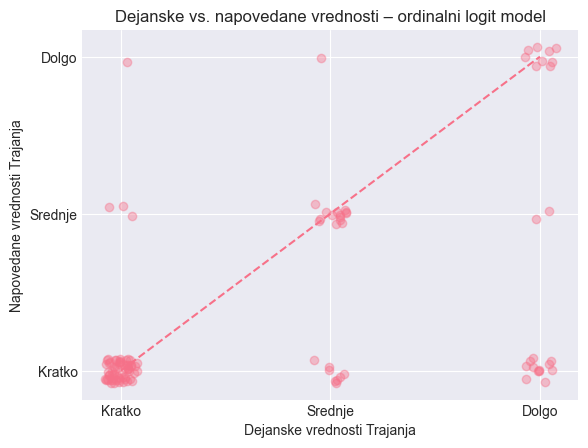

In [101]:
y_true = ordinal_to_codes(y_ord_3)
y_pred = ordinal_to_codes(pred_cat_full)

rng = np.random.default_rng(42)
jitter = 0.08
x = y_true + rng.uniform(-jitter, jitter, size=len(y_true))
y = y_pred + rng.uniform(-jitter, jitter, size=len(y_pred))

plt.figure()
plt.scatter(x, y, alpha=0.4)
plt.plot([1, 3], [1, 3], linestyle="--")

plt.xticks([1, 2, 3], ["Kratko", "Srednje", "Dolgo"])
plt.yticks([1, 2, 3], ["Kratko", "Srednje", "Dolgo"])

plt.xlabel("Dejanske vrednosti Trajanja")
plt.ylabel("Napovedane vrednosti Trajanja")
plt.title("Dejanske vs. napovedane vrednosti – ordinalni logit model")

plt.show()

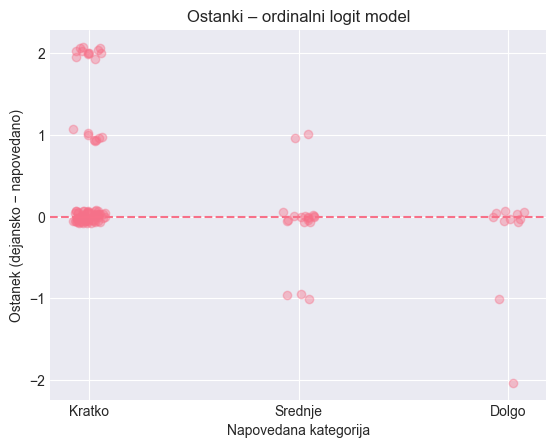

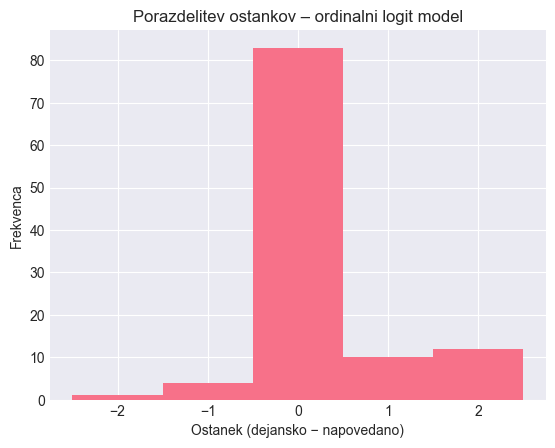

In [103]:

y_true = ordinal_to_codes(y_ord_3)
y_pred = ordinal_to_codes(pred_cat_full)

resid = y_true - y_pred

rng = np.random.default_rng(42)
jitter = 0.08
x = y_pred + rng.uniform(-jitter, jitter, size=len(y_pred))
y = resid + rng.uniform(-jitter, jitter, size=len(resid))

plt.figure()
plt.scatter(x, y, alpha=0.4)
plt.axhline(0, linestyle="--")

plt.xticks([1, 2, 3], ["Kratko", "Srednje", "Dolgo"])
plt.yticks([-2, -1, 0, 1, 2])

plt.xlabel("Napovedana kategorija")
plt.ylabel("Ostanek (dejansko − napovedano)")
plt.title("Ostanki – ordinalni logit model")
plt.show()

plt.figure()
plt.hist(resid, bins=[-2.5, -1.5, -0.5, 0.5, 1.5, 2.5])
plt.xticks([-2, -1, 0, 1, 2])
plt.xlabel("Ostanek (dejansko − napovedano)")
plt.ylabel("Frekvenca")
plt.title("Porazdelitev ostankov – ordinalni logit model")
plt.show()


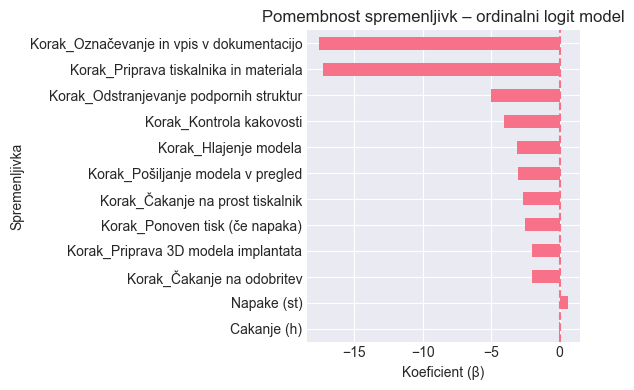

In [104]:
coef = ordinal_res_3.params
coef = coef[~coef.index.str.contains("/")]

coef_sorted = coef.reindex(coef.abs().sort_values().index)

plt.figure(figsize=(6, 4))
coef_sorted.plot(kind="barh")
plt.axvline(0, linestyle="--")

plt.xlabel("Koeficient (β)")
plt.ylabel("Spremenljivka")
plt.title("Pomembnost spremenljivk – ordinalni logit model")

plt.tight_layout()
plt.show()

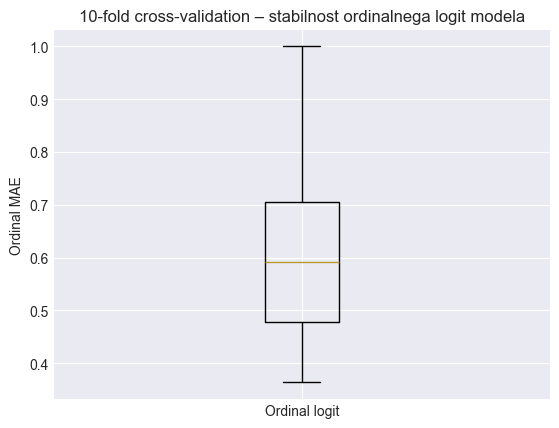

In [ ]:
plt.figure()
plt.boxplot(mae_ord_logit, vert=True)
plt.ylabel("Ordinal MAE")
plt.title("10-fold cross-validation - stabilnost ordinalnega logit modela")
plt.xticks([1], ["Ordinal logit"])
plt.show()

## Katere spremenljivke imajo največji vpliv in v katero smer?
Največji vpliv imajo **procesni koraki (*Korak*)**, pri čemer so ključni koraki povezani z **negativnimi koeficienti**, kar pomeni **krajše trajanje procesa**.

---

## Kako dobro model pojasni izid?
Model ima **zmerno pojasnjevalno moč**, saj dosega **pseudo-R² ≈ 0,26**.

---

## Kako stabilni so rezultati med ponovitvami?
Rezultati so **zmerno stabilni**, kar potrjuje **10-fold križna validacija** z **ordinalno MAE ≈ 0,61** in razmeroma majhnim raztrosom.

---

## Kako bi uporabili ta model za izboljšavo procesa (Six Sigma – Improve phase)?
Model bi uporabili za **prepoznavo in optimizacijo kritičnih procesnih korakov** ter za **zmanjševanje variabilnosti in ponovitev v procesu**.
